# Intro

- Recoding of https://github.com/Daniel-EST/deep-steganography/ but updated to match modern tensorflow or pytorch depending what is easiest to use
- from paper: 500 training images, 50 validation images, and 50 test images, all uniformly resized to a manageable dimension of 64x64x3 pixels
    - with rbg colour (no greyscale) to ease training

- overall process:
  - get text which is small enough *after* huffman encoding to fit within 64*64*3 sized block, and encode within image using LSB resulting in **secret image** which will be used by NN (for training all will be encoded with *"Hello World!"* just to keep things simple, but randomized text could be more authentic)
    - LSB - use pillow library (https://pypi.org/project/pillow/) to ease implementation
    - Huffman will also be from GeeksForGeeks / public implementation to speed development
  - NN will be three layers a preperation > hide > reveal networks (with each being NNs) that will ideally allow for full reconstruction of secret image
  - finally undo LSB + Huffman to retrieve final text and check accordingly.

- Issues so far:
  - Deep stenography is greatly outdated so fixing has not been very easy, could promp re-scope of assign to meet deadline if it is unable to be done
  - reformatting between secret image > steg image > revealed secret causes issues with LSB where unless its 100% (>90% ssim) then final classical steganography cannot be performed often
  - could add scheduler to improve flattening learning rate after x epochs and this could benefit the issues with too much noise ruining secret text recovery.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

from dahuffman import HuffmanCodec

# huffman serialization assisted with chatgpt for debugging, dahuffman use from PyPl example
def HuffmanEncode(data):
    # encode text into huffman tree + map
    codec = HuffmanCodec.from_data(data)
    encoded_data = codec.encode(data)

    # finally prepend all so tree:data is one block
    return codec, encoded_data

def HuffmanDecode(codec,data):
    # using Huffman map reconstruct text to original values and decode / unzip data
    decoded_data = codec.decode(data)
    return decoded_data

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
tf.config.optimizer.set_jit(True)

In [2]:
from datasets import load_dataset
import certifi
import numpy as np
import math
import random
import time

os.environ['SSL_CERT_FILE'] = certifi.where()
def is_rgb(example):
    return example['image'].mode == 'RGB'
# option 1 uses "Hello World!" for all to reuse codec and make things simpler
temp_data = load_dataset("zh-plus/tiny-imagenet")
tiny_imageNet_rgb = temp_data.filter(is_rgb)

# comment out select for whole dataset, just to test set to 1/4
num_samples = len(tiny_imageNet_rgb['train'])
train_pool = tiny_imageNet_rgb['train'].select(range(num_samples))
test_pool = tiny_imageNet_rgb['valid']

ex_data = "Hello World!"
codec,encoded_data = HuffmanEncode(ex_data)
# 1. Prepare your message mask once (outside the function)
# We convert the binary data into a bit-mask tensor of 0s and 1s
def create_mask(binary_string):
    bit_string = ''.join(format(byte, '08b') for byte in binary_string)
    # Convert "0101..." string to numpy array of 0s and 1s
    bits = np.array([int(b) for b in bit_string], dtype=np.uint8)
    # Pad or tile to fill 64*64*3 = 12288 pixels
    full_bits = np.resize(bits, (64, 64, 3))
    return tf.constant(full_bits, dtype=tf.uint8)

MESSAGE_MASK = create_mask(encoded_data)
random.seed(int(time.time()))

def create_tfrecord(data_pool, output_file, message_mask):
    # 1. Shuffle and pair indices
    indices = list(range(len(data_pool)))
    random.shuffle(indices)
    
    # Convert MESSAGE_MASK to numpy for PIL/Numpy manipulation
    mask_np = MESSAGE_MASK.numpy()

    with tf.io.TFRecordWriter(output_file) as writer:
        for i in range(0, len(indices) - 1, 2):
            # Load images
            img_cover_pil = data_pool[int(indices[i])]['image'].resize((64, 64))
            img_secret_pil = data_pool[int(indices[i+1])]['image'].resize((64, 64))
            
            # Convert Secret to Numpy to apply LSB
            secret_arr = np.array(img_secret_pil, dtype=np.uint8)
            
            # --- LSB METHOD ---
            # Clear the last bit (AND 254) and insert the mask (OR mask)
            # 254 is binary 11111110
            secret_steg_arr = (secret_arr & 254) | mask_np
            # ------------------

            cover_bytes = np.array(img_cover_pil).tobytes()
            secret_bytes = secret_steg_arr.tobytes()

            feature = {
                'cover': tf.train.Feature(bytes_list=tf.train.BytesList(value=[cover_bytes])),
                'secret': tf.train.Feature(bytes_list=tf.train.BytesList(value=[secret_bytes])),
            }
            example = tf.train.Example(features=tf.train.Features(feature=feature))
            writer.write(example.SerializeToString())

# Run for train and test
create_tfrecord(train_pool, 'train_data.tfrecords',MESSAGE_MASK)
create_tfrecord(test_pool, 'test_data.tfrecords',MESSAGE_MASK)
def parse_function(example_proto):
    feature_description = {
        'cover': tf.io.FixedLenFeature([], tf.string),
        'secret': tf.io.FixedLenFeature([], tf.string),
    }
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    
    # 1. Decode Cover
    cover = tf.io.decode_raw(parsed['cover'], tf.uint8)
    cover = tf.reshape(cover, [64, 64, 3])
    cover = tf.cast(cover, tf.float32) / 255.0

    # 2. Decode Secret
    secret = tf.io.decode_raw(parsed['secret'], tf.uint8)
    secret = tf.reshape(secret, [64, 64, 3])    
    secret = tf.cast(secret, tf.float32) / 255.0
    
    return cover, secret

print(f"Pools Ready: {num_samples/2} Train pairs, {len(test_pool)/2} Test pairs.")

Pools Ready: 49089.5 Train pairs, 4916.0 Test pairs.


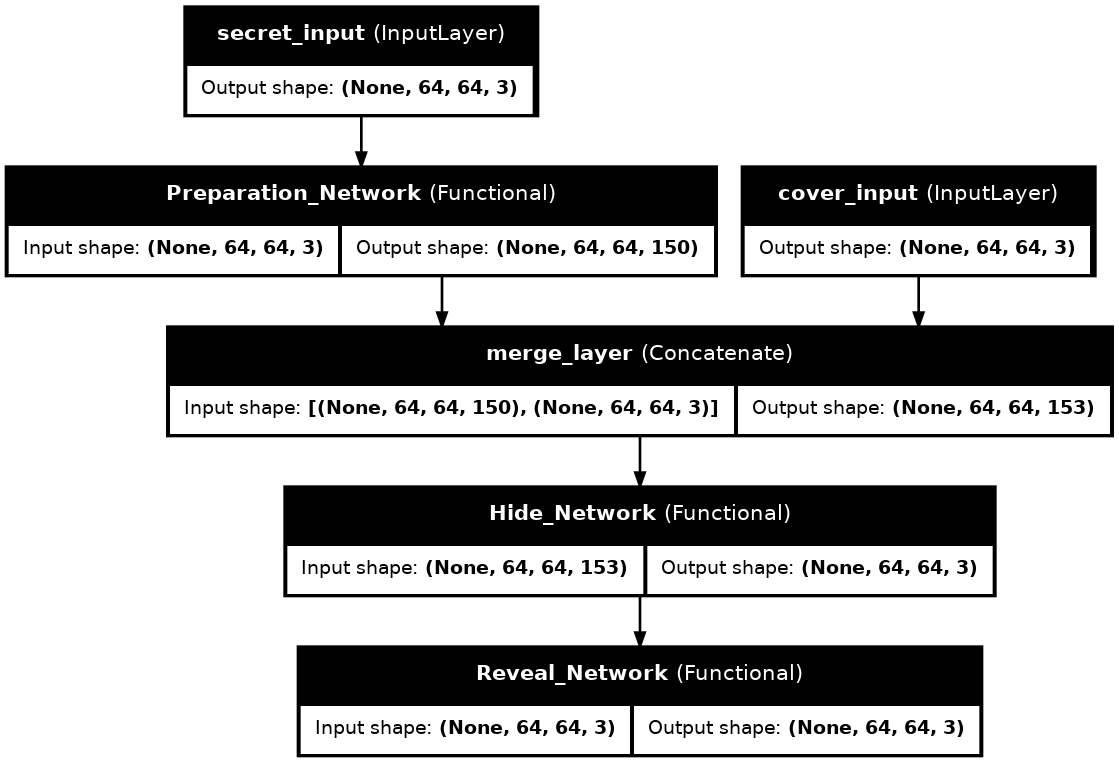

In [3]:
from tensorflow.keras import layers, losses,models
tf.keras.backend.clear_session()
BETA=1
# 1. PREP NETWORK: (None, 64, 64, 3) -> (None, 64, 64, 150)
# Using 50 filters of each size (3x3, 4x4, 5x5) to reach 150
def build_prep():
         # Prep
        secret = layers.Input(shape=(64,64,3),name="prep_input")
        p1_3 = layers.Conv2D(50, (3, 3), padding='same', activation='relu')(secret)
        p1_4 = layers.Conv2D(50, (4, 4), padding='same', activation='relu')(secret)
        p1_5 = layers.Conv2D(50, (5, 5), padding='same', activation='relu')(secret)
        p_concat1 = layers.Concatenate(axis=3)([p1_3, p1_4, p1_5]) # 150 channels

        p2_3 = layers.Conv2D(50, (3, 3), padding='same', activation='relu')(p_concat1)
        p2_4 = layers.Conv2D(50, (4, 4), padding='same', activation='relu')(p_concat1)
        p2_5 = layers.Conv2D(50, (5, 5), padding='same', activation='relu')(p_concat1)
        p_concat2 = layers.Concatenate(axis=3)([p2_3,p2_4,p2_5])
        return models.Model(inputs=secret,outputs=p_concat2, name="Preparation_Network")


# 2. HIDE NETWORK: (None, 64, 64, 150+3) -> (None, 64, 64, 3)
def build_hide():
    # Hide
    hide_in = layers.Input(shape=(64,64,153),name="hide_input")
    h1_3 = layers.Conv2D(50, (3, 3), padding='same', activation='relu')(hide_in)
    h1_4 = layers.Conv2D(50, (4,4), padding='same', activation='relu')(hide_in)
    h1_5 = layers.Conv2D(50, (5,5), padding='same', activation='relu')(hide_in)
    h_concat2 = layers.Concatenate(axis=3)([h1_3,h1_4,h1_5]) # 153 channels

    h2_3 = layers.Conv2D(50, (3, 3), padding='same', activation='relu')(h_concat2)
    h2_4 = layers.Conv2D(50, (4,4), padding='same', activation='relu')(h_concat2)
    h2_5 = layers.Conv2D(50, (5,5), padding='same', activation='relu')(h_concat2)
    h_concat3 = layers.Concatenate(axis=3)([h2_3,h2_4,h2_5]) # 153 channels

    hide_out = layers.Conv2D(3, (1,1), padding='same', activation='relu')(h_concat3)
    return models.Model(inputs=hide_in,outputs=hide_out,name="Hide_Network")


# 3. REVEAL NETWORK: (None, 64, 64, 3) -> (None, 64, 64, 3)
def build_reveal():
    reveal_in = layers.Input(shape=(64,64,3),name="reveal_input")
    r1_3 = layers.Conv2D(50, (3, 3), padding='same', activation='relu')(reveal_in)
    r1_4 = layers.Conv2D(50, (4,4), padding='same', activation='relu')(reveal_in)
    r1_5 = layers.Conv2D(50, (5,5), padding='same', activation='relu')(reveal_in)
    r_concat1 = layers.Concatenate(axis=3)([r1_3,r1_4,r1_5])

    r2_3 = layers.Conv2D(50, (3, 3), padding='same', activation='relu')(r_concat1)
    r2_4 = layers.Conv2D(50, (4,4), padding='same', activation='relu')(r_concat1)
    r2_5 = layers.Conv2D(50, (5,5), padding='same', activation='relu')(r_concat1)
    r_concat2 = layers.Concatenate(axis=3)([r2_3,r2_4,r2_5])

    reveal_out = layers.Conv2D(3, (1,1), padding='same', activation='relu')(r_concat2)
    return models.Model(inputs=reveal_in,outputs=reveal_out,name="Reveal_Network")

class SteganoModel(tf.keras.Model):
    def __init__(self):
        super(SteganoModel, self).__init__()
        self.prep_net = build_prep()
        self.hide_net = build_hide()
        self.reveal_net = build_reveal()

    def call(self, inputs):
        cover, secret = inputs
        prep_out = self.prep_net(secret)
        hide_in = layers.Concatenate(axis=3)([prep_out,cover])
        stego = self.hide_net(hide_in)
        revealed = self.reveal_net(stego)
        return stego, revealed

    @tf.function(jit_compile=True)
    def train_step(self, data):
        # Unpack the data (Expecting cover and secret images)
        cover, secret = data

        with tf.GradientTape() as tape:
            stego,revealed = self([cover,secret],training=True)
            
            # Loss Calculation: total_loss = cover_mse + beta * secret_mse
            cover_mse = tf.reduce_mean(losses.mse(cover, stego))
            secret_mse = tf.reduce_mean(losses.mse(secret, revealed))
            total_loss = cover_mse + (BETA * secret_mse)

        # Apply gradients
        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))
        
        return {"loss": total_loss, "cover_mse": cover_mse, "secret_mse": secret_mse}

# Initialize
model = SteganoModel()
# 1. Instantiate the sub-models
prep_net = build_prep()
hide_net = build_hide()
reveal_net = build_reveal()

# 2. Define the inputs
secret_in = layers.Input(shape=(64, 64, 3), name='secret_input')
cover_in = layers.Input(shape=(64, 64, 3), name='cover_input')

# 3. Connect them (The "Functional" way)
prep_out = prep_net(secret_in)
# This Concatenate layer will show clearly as a merge point in the plot
hide_in = layers.Concatenate(axis=3, name="merge_layer")([prep_out, cover_in])
stego_out = hide_net(hide_in)
revealed_out = reveal_net(stego_out)

# 4. Create the model specifically for plotting
plot_ready_model = models.Model(
    inputs=[cover_in, secret_in], 
    outputs=[stego_out, revealed_out],
    name="Steganography_System"
)

# 5. Plot with expand_nested=False
tf.keras.utils.plot_model(
    plot_ready_model,
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=False, # THIS IS KEY: It keeps the sub-models as single blocks
    dpi=96
)


In [5]:
# --- Training Configuration ---
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),jit_compile=True)

train_ds = tf.data.TFRecordDataset('train_data.tfrecords') \
    .map(parse_function,num_parallel_calls=tf.data.AUTOTUNE) \
    .cache() \
    .shuffle(buffer_size=1000) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='loss', 
    factor=0.5,      # Cut learning rate in half when progress stalls
    patience=5,      # Wait 5 epochs
    min_lr=1e-6,     # Don't go below this
    verbose=1
)

#samples / 2 (because 1 conver + 1 secret / batch)
start_time = time.time()
history = model.fit(
    train_ds, 
    epochs=EPOCHS,
    steps_per_epoch=(math.floor(num_samples/2/BATCH_SIZE)),
    batch_size=BATCH_SIZE,
    callbacks=[lr_scheduler],
    verbose=1
)
# think this is needed to save weights?
end_time = time.time()

total_time = end_time - start_time
print("Training Complete.")
hours = int(total_time // 3600)
minutes = int((total_time % 3600) // 60)
seconds = int(total_time % 60)

epoch_hours = int(total_time/EPOCHS // 3600)
epoch_minutes = int((total_time/EPOCHS % 3600) // 60)
epoch_seconds = int(total_time/EPOCHS % 60)

print(f"Total training time: {hours}h {minutes}m {seconds}s, time/epoch: {epoch_hours}h {epoch_minutes}m {epoch_seconds}s")

Epoch 1/100
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 762s 475ms/step - cover_mse: 0.0035 - loss: 0.0086 - secret_mse: 0.0051 - learning_rate: 0.0010
Epoch 2/100
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 12s 11us/step - cover_mse: 0.0051 - loss: 0.0081 - secret_mse: 0.0029 - learning_rate: 0.0010
Epoch 3/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1534/1534 ━━━━━━━━━━━━━━━━━━━━ 728s 475ms/step - cover_mse: 0.0033 - loss: 0.0073 - secret_mse: 0.0040 - learning_rate: 0.0010
Epoch 4/100
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 0s 7us/step - cover_mse: 0.0169 - loss: 0.0196 - secret_mse: 0.0027 - learning_rate: 0.0010
Epoch 5/100
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 727s 474ms/step - cover_mse: 0.0028 - loss: 0.0053 - secret_mse: 0.0025 - learning_rate: 0.0010
Epoch 6/100
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 0s 13us/step - cover_mse: 0.0011 - loss: 0.0030 - secret_mse: 0.0019 - learning_rate: 0.0010
Epoch 7/100
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 728s 474ms/step - cover_mse: 0.0021 - loss: 0.0041 - secret_mse: 0.0020 - learning_rate: 0.0010
Epoch 8/100
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 0s 6us/step - cover_mse: 0.0046 - loss: 0.0178 - secret_mse: 0.0132 - learning_rate: 0.0010
Epoch 9/100
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 726s 473ms/step - cover_mse: 0.0028 - loss: 0.0072 - secret_mse: 0.0044 - learning_rate: 0.0010
Epoch 10/100
1534/1534 ━━━━━━━━━━━━━━━━━━━━ 0s 8us

In [6]:
# Save the whole model weights
model.save('steganography_model.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Recovered text: e
Metrics for Secret vs Revealed:
PSNR: 26.63 dB
SSIM: 0.9667
AccTxt: 0.0000


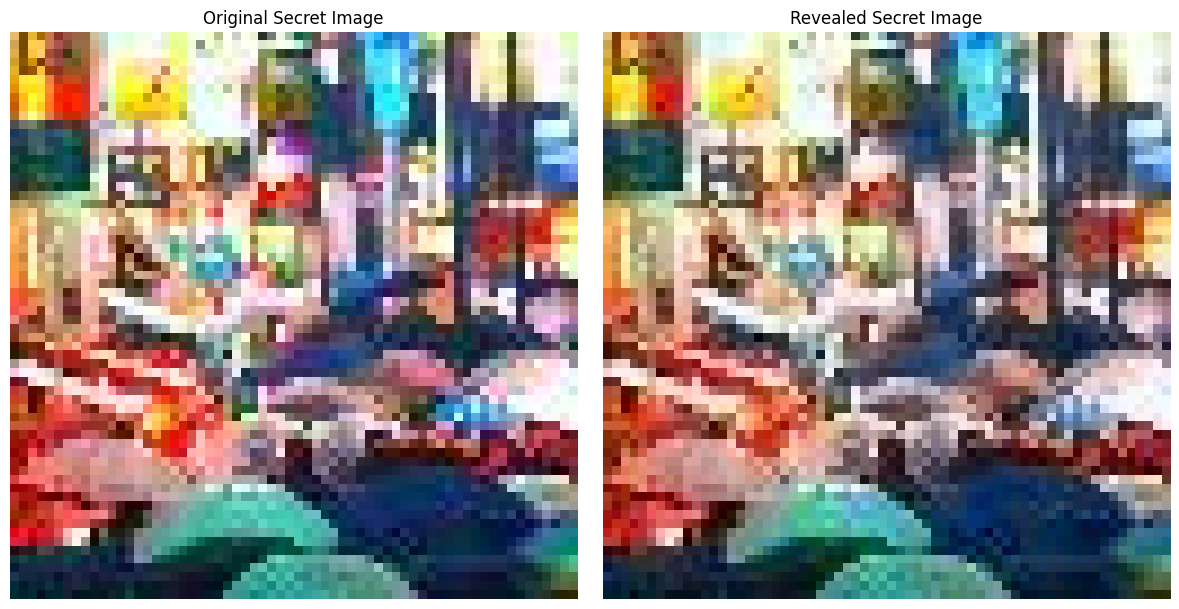

In [7]:
import matplotlib.pyplot as plt

def calculate_metrics(img1, img2):
    # Ensure inputs are tensors
    img1 = tf.convert_to_tensor(img1)
    img2 = tf.convert_to_tensor(img2)
    
    # If the images don't have a batch dimension (shape H,W,C), add one
    if len(img1.shape) == 3:
        img1 = tf.expand_dims(img1, axis=0)
    if len(img2.shape) == 3:
        img2 = tf.expand_dims(img2, axis=0)

    # Calculate metrics
    psnr = tf.image.psnr(img1, img2, max_val=1.0)
    ssim = tf.image.ssim(img1, img2, max_val=1.0)
    
    # .numpy() now returns an array, so [0] will work correctly
    return psnr.numpy()[0], ssim.numpy()[0]

def vectorized_lsb_extract(steg_image_tensor):
    """
    steg_image_tensor: (H, W, 3) uint8 tensor (0-255)
    Returns: (H, W, 3) uint8 tensor containing only 0s and 1s
    """
    # Bitwise AND with 1 extracts the last bit
    extracted_bits = tf.bitwise.bitwise_and(steg_image_tensor, 1)
    return extracted_bits

def bits_to_bytes(bits_tensor):
    """
    Converts a tensor of bits (0s and 1s) into a bytearray.
    """
    # 1. Flatten the tensor to a 1D array of bits
    # Use .numpy() if it's a EagerTensor
    flattened_bits = np.array(bits_tensor).flatten()
    
    # 2. Ensure we only take bits that complete a full byte (multiples of 8)
    num_bits = (len(flattened_bits) // 8) * 8
    flattened_bits = flattened_bits[:num_bits]
    
    # 3. Reshape into (N, 8) where N is the number of bytes
    bit_groups = flattened_bits.reshape(-1, 8)
    
    # 4. Pack bits into integers (0-255)
    # We multiply by powers of 2: [128, 64, 32, 16, 8, 4, 2, 1]
    powers_of_two = 2 ** np.arange(7, -1, -1)
    byte_values = np.dot(bit_groups, powers_of_two).astype(np.uint8)
    
    return bytearray(byte_values)

test_ds = tf.data.TFRecordDataset('test_data.tfrecords') \
    .map(parse_function,num_parallel_calls=tf.data.AUTOTUNE) \
        .shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

for cover, secret in test_ds.take(1):
    stego, revealed = model.predict([cover,secret])
    cover_img = np.clip(cover[0],0,1)
    secret_img = np.clip(secret[0],0,1)
    stego_img = np.clip(stego[0],0,1)
    revealed_img = np.clip(revealed[0],0,1)
    final_acc = 0.0
    try:
        # Convert model output [0, 1] float back to [0, 255] uint8
        revealed_uint8 = (revealed_img[0] * 255).clip(0, 255).astype(np.uint8)
        
        # 2. Extract bits using the vectorized function
        bits = vectorized_lsb_extract(tf.convert_to_tensor(revealed_uint8))
        
        # 3. Pack bits into bytes
        extracted_bin = bits_to_bytes(bits)

        # 4. Decode Huffman
        final_text = HuffmanDecode(codec, extracted_bin)
        
        # Optional: Truncate to original text length to ignore Huffman padding
        final_text = final_text[:len(ex_data)]
        
        print(f"Recovered text: {final_text}")
        matches = sum(1 for a,b in zip(ex_data,final_text) if a==b)
        final_acc = (matches / len(ex_data)) * 100
    except Exception as e:
        print(f"Extraction failed due to: {e}")

    # 3. Print quantitative metrics for context
    psnr_val, ssim_val = calculate_metrics(secret_img,revealed_img)

    print(f"Metrics for Secret vs Revealed:")
    print(f"PSNR: {psnr_val:.2f} dB")
    print(f"SSIM: {ssim_val:.4f}")
    print(f"AccTxt: {final_acc:.4f}")
    plt.figure(figsize=(12, 6))

    # Original Secret Image
    plt.subplot(1, 2, 1)
    plt.title("Original Secret Image")
    plt.imshow(secret_img)
    plt.axis('off')

    # Revealed Secret Image
    plt.subplot(1, 2, 2)
    plt.title("Revealed Secret Image")
    plt.imshow(revealed_img)
    plt.axis('off')

    plt.tight_layout()
    plt.show()